# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

Overall years of experience show no signs of improving focus, although I did notice a great focus increas based off of desk placementt. Open floor was a lot harder for people to focus. Remote workes seemed to be amongst some of the highest proficent. Meetings did not affect overall productivity

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv('Employee_productivity.csv')

In [4]:
df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


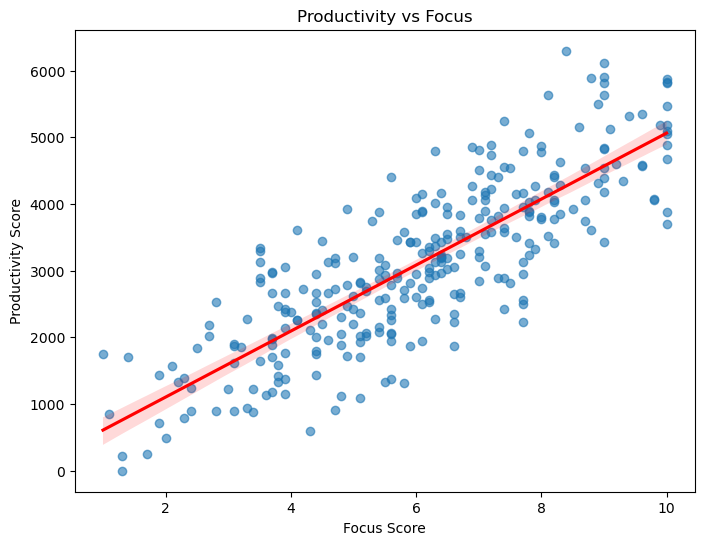

In [5]:
plt.figure(figsize=(8,6))
sns.regplot(data=df, x="FocusScore", y="ProductivityScore", scatter_kws={"alpha":0.6}, line_kws={"color":"red"})
plt.title("Productivity vs Focus")
plt.xlabel("Focus Score")
plt.ylabel("Productivity Score")
plt.show()

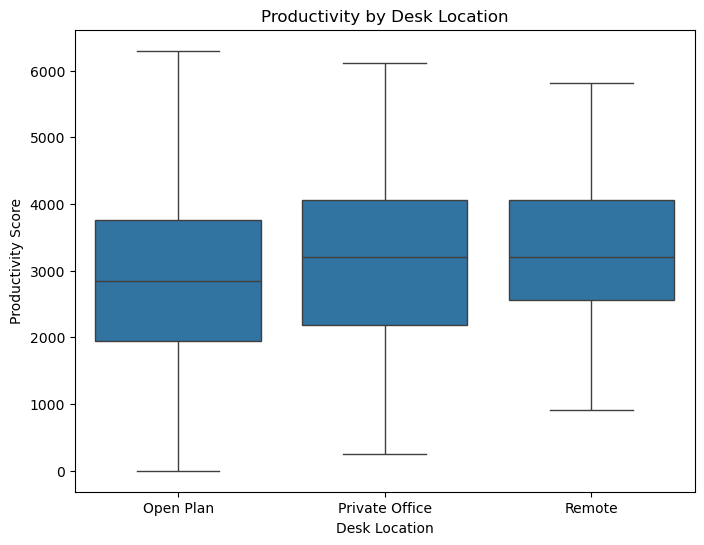

In [6]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="DeskLocation", y="ProductivityScore")
plt.title("Productivity by Desk Location")
plt.xlabel("Desk Location")
plt.ylabel("Productivity Score")
plt.show()

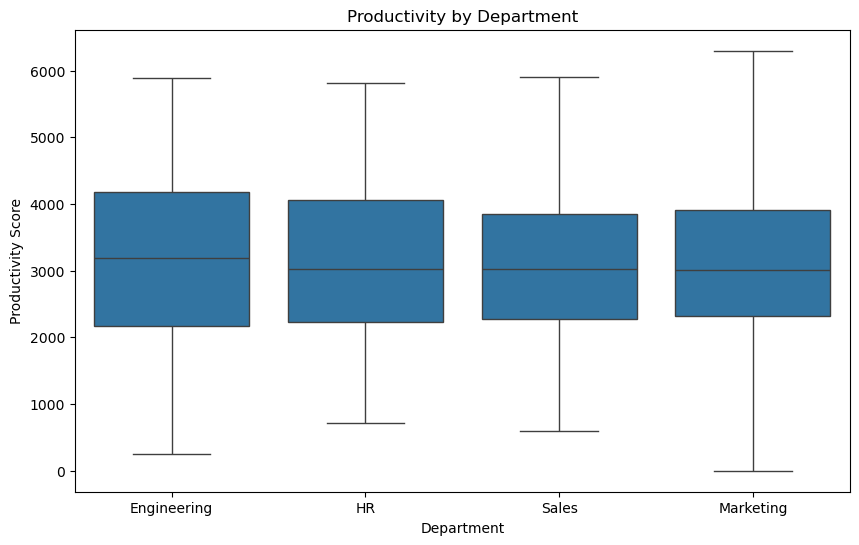

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Department", y="ProductivityScore")
plt.title("Productivity by Department")
plt.xlabel("Department")
plt.ylabel("Productivity Score")
plt.show()

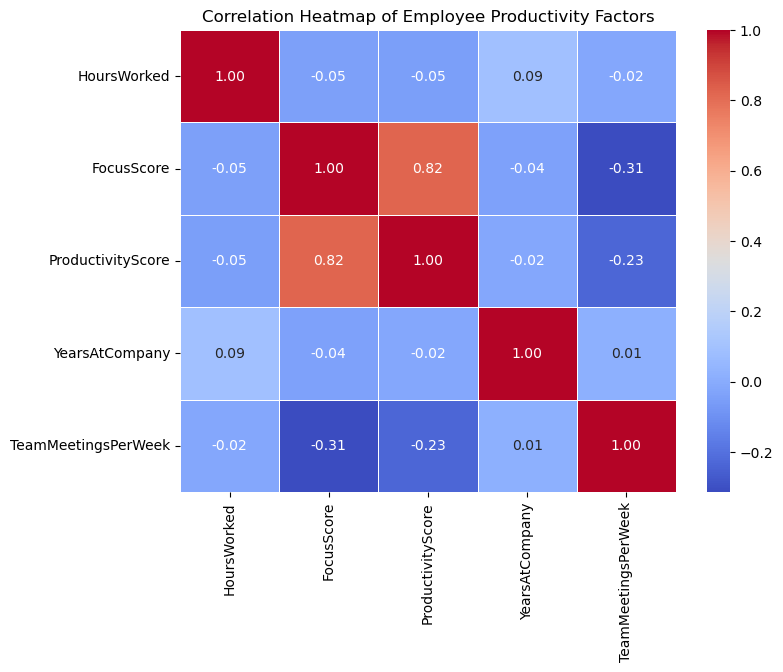

In [10]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Employee Productivity Factors")
plt.show()

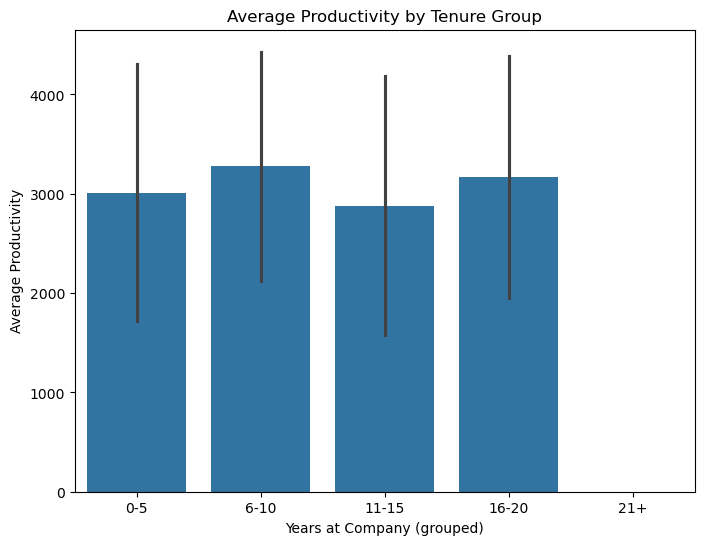

In [13]:
df['TenureGroup'] = pd.cut(df['YearsAtCompany'], bins=[0,5,10,15,20,30], 
                           labels=["0-5","6-10","11-15","16-20","21+"])

plt.figure(figsize=(8,6))
sns.barplot(data=df, x="TenureGroup", y="ProductivityScore", estimator="mean", errorbar="sd")
plt.title("Average Productivity by Tenure Group")
plt.xlabel("Years at Company (grouped)")
plt.ylabel("Average Productivity")
plt.show()

In [27]:
df_encoded = pd.get_dummies(df, columns=["Department", "DeskLocation"], drop_first=True)

# Features and target
X = df_encoded.drop("ProductivityScore", axis=1)
y = df_encoded["ProductivityScore"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression().fit(X_train, y_train)

# Overall R²
y_pred = model.predict(X_test)
print("Overall R²:", round(r2_score(y_test, y_pred), 2))

Overall R²: 0.61
